# Notebook 4: Inference I, Hypothesis Testing, t-tests and Power

*Quantitative Methods in Neuroscience, Master in Neuroscience, University of Geneva (2026-27)*

This is the practical companion to **Lecture 4, Hypothesis Testing, t-tests and Power**.

Week 3 ended with a number: the difference in prior-updating shift between the wild-type and
the Cntnap2 mice, expressed in units of the standard deviation. We deliberately stopped there and
refused to say whether it was "significant". This week we earn the right to say it, and we find
out what the word does and does not mean.

The logic is worth stating once, in plain language, because everything else follows from it.
**Assume there is no effect. Work out how often an experiment like yours would produce a result
at least as extreme as the one you got, purely by luck. If that turns out to be rare enough, that is
to say very unlikely,
stop believing the assumption.** That is the whole of a hypothesis test. Note what it never does: it 
never proves there is no effect, and it never tells you how big the effect is.

### By the end of this notebook you will be able to:
- State a **null** and an **alternative** hypothesis, and choose between one- and two-sided.
- Explain what a **p-value** is by simulating the null and watching p-values come out flat.
- Distinguish **Type I** from **Type II** errors, and compute **power** by simulation.
- Run the three t-tests in `scipy.stats`: **one-sample**, **two-sample** and **paired**.
- Implement a two-sample t-test **from its formula** and check it against scipy.
- Choose between **Student** and **Welch** using the assumptions, with conditional logic.
- Report an effect properly: **t, p, Cohen's d and a confidence interval**, not just a p-value.
- Work out, by simulation, **how many mice** an experiment like this one would need.

### Table of contents
0. [Setting up and recovering the measurement](#section-0)
1. [The logic of a test](#section-1)
   - 1.1 [Null, alternative, alpha](#section-1-1)
   - 1.2 [What a p-value actually is](#section-1-2)
   - 1.3 [Two ways to be wrong, and power](#section-1-3)
   - 1.4 [A first real test](#section-1-4)
2. [Building the t-test](#section-2)
   - 2.1 [The test statistic](#section-2-1)
   - 2.2 [From scratch, against scipy](#section-2-2) 🔬
   - 2.3 [Assumptions: Student or Welch](#section-2-3)
   - 2.4 [Effect size and confidence interval](#section-2-4)
3. [Inference on the real data](#section-3)
   - 3.1 [Three comparisons](#section-3-1)
   - 3.2 [The paired version](#section-3-2)
   - 3.3 [Power, and why n = 10 is a small sample](#section-3-3)
   - 3.4 [Report one yourself](#section-3-4)
4. [What comes next](#section-4)

> **How to read this notebook.** Markdown cells explain the concept, code cells implement it.
> **`▶ Task`** boxes are exercises, tagged by difficulty:
>
> - **⭐** essential: run it, understand it, change it slightly.
> - **⭐⭐** intermediate: complete the missing lines or write a short function.
> - **⭐⭐⭐** optional challenge: build a fuller analysis yourself.
>
> Some section titles carry a **🔬**. Those sections go further than the course strictly
> requires, and you can skip them lightheartedly: nothing that comes afterwards will stop making
> sense. Each one says in a line why it is there and whether the material comes back later. Tasks
> inside a 🔬 section are optional too, whatever their stars.
>
> If you get stuck, ask the TAs. If you use AI help, treat it as a tutor and not a substitute:
> you should be able to read every line and say what it does. We suggest the custom bot
> prepared for this course: https://chatgpt.com/g/g-69fc9bfc9a748191a912a124800d9254-qmn-teaching-assistant-bot (to access sign in with a free OpenAI account)

<a id="section-0"></a>
## 0. Setting up and recovering the measurement

> **Before you run anything**, make sure the course conda environment **`qmn`** is active, or
> selected as this notebook's kernel in VS Code. If you have not created it yet, follow the
> illustrated setup guide, `QMN_setup_guide_students.pdf`, or its plain text twin
> `SETUP_INSTRUCTIONS.txt`, both on Moodle.

One new library this week. [SciPy](https://scipy.org/) is the scientific toolbox built on top of
NumPy, and the part of it we need is `scipy.stats`, which holds the standard statistical tests
and the probability distributions they rely on. Rather than an alias, we import the submodule
itself using the command:
>from scipy import stats

so that a test is called as `stats.ttest_ind(...)`.

We also rebuild the measurement from Week 3, section 3.4, since we will test it all week. As
a reminder of what it is: in the trained phase the stimulus is more likely on one side for a
block of trials, either 20% or 80% on the left. On **zero-contrast** trials there is nothing to
see, so the only thing a mouse can go on is that block prior. The **prior-updating shift** is how
far its choices move between the two block types, one number per mouse.

In [1]:
# Where the data and the shared helpers live. This works whether the notebook
# is opened from notebooks/ or from a subfolder of it.
import sys
from pathlib import Path

# sys.path is the list of folders Python searches when you import something. Adding ROOT to it
# means our own `src` folder is importable too, whatever folder you started the notebook from.

ROOT = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
print("ROOT =", ROOT)

ROOT = C:\Users\matteucc\Documents\QMN_course\notebooks


In [2]:
# --- Import the scientific Python stack
import numpy as np                  # import of NumPy library: numerical arrays and maths
import pandas as pd                 # import of pandas library: tables of data (DataFrames)
import matplotlib.pyplot as plt     # import of Matplotlib library: plotting
import seaborn as sns               # import of seaborn library: statistical plots in one line
from scipy import stats             # import of SciPy's stats module: tests and distributions
from cycler import cycler           # to set our own default colour sequence
from IPython.display import display # shows a DataFrame as a formatted table

# A bit of style for every figure in this notebook (feel free to tweak it)
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=["#1f77b4", "#ff7f0e", "#5b2c83"]),
})

# One colour per cohort, used consistently in every figure below.
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}
COHORT_ORDER = ["CSHL-WT", "NYU-WT", "CSP-ASD"]

print(f"pandas : {pd.__version__}")
print(f"scipy  : {stats.__name__.split('.')[0]} {__import__('scipy').__version__}")

pandas : 3.0.2
scipy  : scipy 1.17.1


In [3]:
# --- Rebuild the per-mouse prior-updating shift (Week 3, section 3.4)
trials = pd.read_csv(ROOT / "data" / "ibl_2afc.csv.gz")
mice = pd.read_csv(ROOT / "data" / "ibl_2afc_subjects.csv")

# Step 1: the cohort label, built exactly as in Week 3. Everyone starts as the ASD model,
# then each mask overwrites the rows it selects.
mice["cohort"] = "CSP-ASD"
mice.loc[mice["group"] == "WT", "cohort"] = "NYU-WT"          # the wild-type mice
mice.loc[mice["lab"] == "churchlandlab", "cohort"] = "CSHL-WT"  # those of them trained at CSHL

# Step 2: attach the per-mouse labels to every trial.
trials = trials.merge(mice[["subject_id", "cohort", "group", "sex"]], on="subject_id")
print(f"{len(trials):,} trials from {trials['subject_id'].nunique()} mice")

# Step 3: keep the trained phase without no-go trials, then the zero-contrast trials of the
# biased blocks only (a probability of 0.5 means the block was unbiased).
trained = trials[(trials["phase"] == "trained") & (~trials["no_go"])]
zero = trained[(trained["signed_contrast"] == 0) & (trained["probability_left"] != 0.5)]
print("zero-contrast trials in biased blocks:", len(zero))

# Step 4: one mean per mouse per block type, exactly as in Week 3 section 3.4.
def mean_response_per_mouse(block_trials, column_name):
    """Mean of `response` per mouse, as a two column table: subject_id and column_name."""
    out = block_trials.groupby("subject_id")["response"].mean().reset_index()
    return out.rename(columns={"response": column_name})

right_likely = mean_response_per_mouse(zero[zero["probability_left"] == 0.2],
                                       "p_right_pleft_0.2")
left_likely = mean_response_per_mouse(zero[zero["probability_left"] == 0.8],
                                      "p_right_pleft_0.8")

# Step 5: put them side by side, take the difference, and attach the per-mouse labels.
shift = right_likely.merge(left_likely, on="subject_id")
shift["shift"] = shift["p_right_pleft_0.2"] - shift["p_right_pleft_0.8"]
shift = shift.merge(mice[["subject_id", "cohort", "sex"]], on="subject_id")

print("\nthe per-mouse shift, by cohort:")
print(shift.groupby("cohort")["shift"].agg(n="size", mean="mean", sd="std")
           .reindex(COHORT_ORDER).round(4).to_string())
display(shift.head())

694,182 trials from 30 mice
zero-contrast trials in biased blocks: 32376

the per-mouse shift, by cohort:
          n    mean      sd
cohort                     
CSHL-WT  10  0.3902  0.1108
NYU-WT   10  0.2924  0.0752
CSP-ASD  10  0.2265  0.0530


,subject_id,p_right_pleft_0.2,p_right_pleft_0.8,shift,cohort,sex
0,CSHL045,0.814985,0.321637,0.493347,CSHL-WT,M
1,CSHL046,0.800363,0.461672,0.338691,CSHL-WT,M
2,CSHL047,0.948419,0.797806,0.150614,CSHL-WT,M
3,CSHL049,0.557169,0.172876,0.384292,CSHL-WT,M
4,CSHL051,0.762681,0.303653,0.459028,CSHL-WT,F


<a id="section-1"></a>
# Part 1. The logic of a test

<a id="section-1-1"></a>
## 1.1 Null, alternative, alpha

A test starts by writing down two statements.

- The **null hypothesis** H0 is the boring one: no difference, no effect, the two groups come
  from the same process. It is the hypothesis we assume while computing, and the one we try to
  refute.
- The **alternative** H1 is what we entertain if H0 becomes untenable: there is a difference.

The alternative can be **two-sided** ("the groups differ, in either direction") or **one-sided**
("group A is larger"). Two-sided is the honest default. A one-sided test is only legitimate when
a difference in the other direction would be as uninteresting as no difference at all, and you
committed to that before seeing the data.

Then we pick **alpha**, the error rate we are willing to tolerate: the probability of rejecting
H0 when it is in fact true. By convention alpha = 0.05, which is a social agreement rather than a
law of nature, and one worth being slightly suspicious of.

<a id="section-1-2"></a>
## 1.2 What a p-value actually is

The p-value is the probability, **if H0 were true**, of getting a result at least as extreme as
the one observed. It is not the probability that H0 is true, and it is not the probability that
your finding is a fluke. Those are the two most common misreadings, and the fastest cure is to
simulate a world where H0 is exactly true and look at what p-values do there.

Below we draw two samples from the **same** distribution, so there is no difference by
construction, test them, and repeat five thousand times.

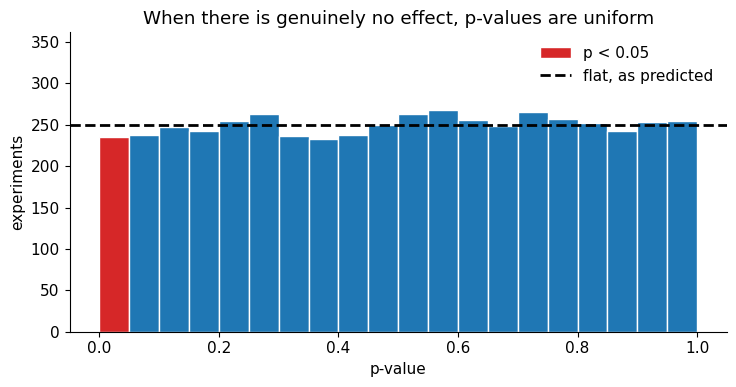

experiments with p < 0.05 : 0.047  (alpha was 0.05)
experiments with p < 0.01 : 0.008  (alpha was 0.01)


In [4]:
# --- p-values when the null is true: five thousand experiments with no effect
rng = np.random.default_rng(0) # set generator to a fixed seed for reproducibility

n_per_group = 10

def p_value_of_one_experiment(true_effect, rng, n_per_group=10):
    """Run one two-group experiment and return its p-value.

    The first group is drawn with mean `true_effect` and the second with mean 0, both with a
    standard deviation of 1. So `true_effect` is the difference measured in standard
    deviations, which is exactly Cohen's d.
    """
    group_a = rng.normal(true_effect, 1.0, n_per_group)
    group_b = rng.normal(0.0, 1.0, n_per_group)
    result = stats.ttest_ind(group_a, group_b, equal_var=False)   # Welch, the safer default
    return result.pvalue

# five thousand experiments in a world where the two groups really are identical
p_null = []
for _ in range(5000):
    p_null.append(p_value_of_one_experiment(0.0, rng, n_per_group))   # no effect at all

p_null = np.array(p_null)      # a list of 5000 p-values, turned into an array

fig, ax = plt.subplots(figsize=(7.5, 4))
# 20 bins across 0 to 1 makes each bin 0.05 wide, so the first bin is exactly p < 0.05.
# ax.hist hands back three things: the count in each bin, the bin edges, and the bars
# themselves, and having the bars lets us recolour one of them.
counts, edges, bars = ax.hist(p_null, bins=20, range=(0, 1), color="#1f77b4",
                              edgecolor="white")
bars[0].set_facecolor("#d62728")          # colour the significant experiments
bars[0].set_label("p < 0.05")             # and give that bar its own legend entry
ax.axhline(len(p_null) / 20, color="black", lw=2, ls="--",
           label="flat, as predicted")     # horizontal reference line at 5000 / 20
ax.set_xlabel("p-value")
ax.set_ylabel("experiments")
ax.set_title("When there is genuinely no effect, p-values are uniform")
ax.set_ylim(0, counts.max() * 1.35)   # headroom, so the legend sits clear of the bars
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

print(f"experiments with p < 0.05 : {(p_null < 0.05).mean():.3f}  (alpha was 0.05)")
print(f"experiments with p < 0.01 : {(p_null < 0.01).mean():.3f}  (alpha was 0.01)")

The histogram is flat. Under the null, every p-value is equally likely, and that is exactly what
makes alpha meaningful: choosing 0.05 guarantees a 5% false-positive rate, no more and no less.

It also shows the danger in one picture. There is nothing whatsoever to find in that simulation,
and yet about one experiment in twenty came out "significant", which is what the printed fraction
says. Run enough tests on nothing and you will publish nothing, with a p-value attached.

<a id="section-1-3"></a>
## 1.3 Two ways to be wrong, and power

|  | H0 is true | H0 is false |
|---|---|---|
| **we reject H0** | Type I error (false positive), rate alpha | correct detection, rate = **power** |
| **we keep H0** | correct, rate 1 - alpha | Type II error (false negative), rate beta |

**Power** is the probability of detecting an effect that is really there, 1 - beta. It depends on
three things: how big the effect is, how variable the data are, and how many observations you
collect. The first two are the world's business; only the third is yours.

Now the same simulation, but with a real difference put in.

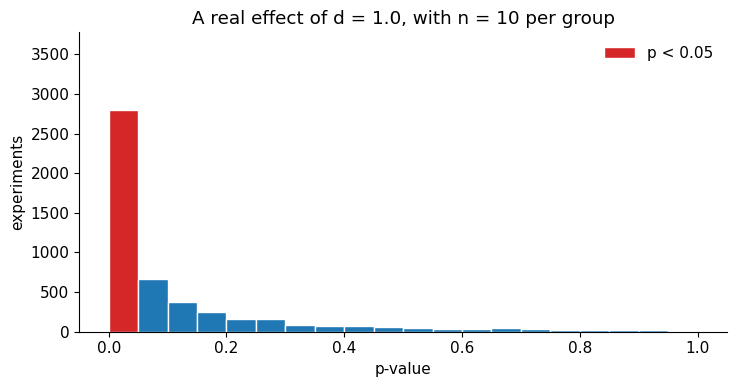

power at n = 10 per group, d = 1.0: 0.560
so 44% of these experiments MISS an effect that is really there


In [5]:
# --- p-values when the null is false: the same experiment with a real effect
rng = np.random.default_rng(1)
true_effect = 1.0        # in standard deviations: a large effect, Cohen's d = 1

# the same five thousand experiments, but now the effect is really there
p_effect = []
for _ in range(5000):
    p_effect.append(p_value_of_one_experiment(true_effect, rng, n_per_group))

p_effect = np.array(p_effect)

fig, ax = plt.subplots(figsize=(7.5, 4))
counts, edges, bars = ax.hist(p_effect, bins=20, range=(0, 1), color="#1f77b4",
                              edgecolor="white")
bars[0].set_facecolor("#d62728")          # again, the first bin is p < 0.05
bars[0].set_label("p < 0.05")
ax.set_xlabel("p-value")
ax.set_ylabel("experiments")
ax.set_title(f"A real effect of d = {true_effect}, with n = {n_per_group} per group")
ax.set_ylim(0, counts.max() * 1.35)   # headroom, so the legend sits clear of the bars
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

power = (p_effect < 0.05).mean()
print(f"power at n = {n_per_group} per group, d = {true_effect}: {power:.3f}")
print(f"so {100 * (1 - power):.0f}% of these experiments MISS an effect that is really there")

That last number deserves a moment. The effect is large by any standard, it is genuinely present
in every one of the five thousand simulated experiments, and with ten animals per group a
substantial fraction of them fail to detect it. A non-significant result is not evidence of
absence; quite often it is evidence of a small sample.

<a id="section-1-4"></a>
## 1.4 A first real test

Time to use the real data. Here is a question with an obvious null: **do trained mice use the
block prior at all?**

On zero-contrast trials the stimulus carries no information, but the rewarded side is still drawn
according to the block probability. A mouse that ignores the blocks should be correct on about
half of them. A mouse that follows the prior should do better than chance. So:

- H0: mean accuracy at zero contrast is 0.5
- H1: it is not 0.5 (two-sided, because we should be prepared to be surprised)

One number per mouse, thirty mice, and a **one-sample t-test** against 0.5.

n mice          : 30
mean accuracy   : 0.5898
t(29)          : 13.850
p-value         : 2.58e-14


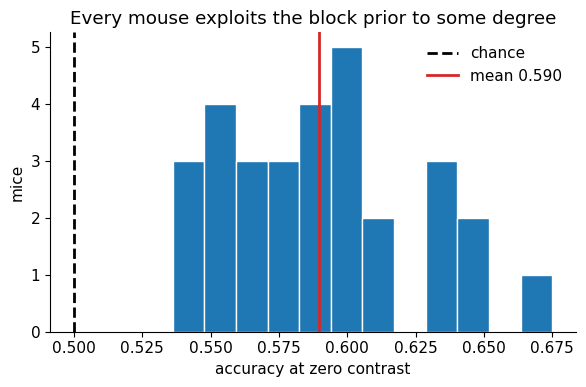

In [6]:
# --- Are trained mice above chance on zero-contrast trials?
zero_acc = zero.groupby("subject_id")["correct"].mean()

# perform a one-sample t-test against the null hypothesis that the mean accuracy is 0.5 (chance level)
result = stats.ttest_1samp(zero_acc, popmean=0.5)
print(f"n mice          : {len(zero_acc)}")
print(f"mean accuracy   : {zero_acc.mean():.4f}")
# access the t-statistic from the result object
print(f"t({len(zero_acc) - 1})          : {result.statistic:.3f}")
print(f"p-value         : {result.pvalue:.2e}") # access the p-value from the result object

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(zero_acc, bins=12, color="#1f77b4", edgecolor="white")
ax.axvline(0.5, color="black", lw=2, ls="--", label="chance")  # vertical reference line
ax.axvline(zero_acc.mean(), color="#d62728", lw=2, label=f"mean {zero_acc.mean():.3f}")
ax.set_xlabel("accuracy at zero contrast")
ax.set_ylabel("mice")
ax.set_title("Every mouse exploits the block prior to some degree")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

> **▶ Task 1.1 ⭐ - Run a test and read the decision.**
> Using `zero_acc` from the cell above:
> 1. Re-run the one-sample test against a null of 0.55 instead of 0.5. Does the conclusion change?
> 2. Print the decision ("reject" or "do not reject") for alpha = 0.05 and for alpha = 0.001,
>    using an `if` statement.
> 3. In a comment: the p-value in the cell above is extremely small. Does that mean the effect is
>    large? Answer in one sentence.

In [7]:
# TODO 1.1 - fill in the blanks marked ____, uncomment, and run.

# for null_value in [0.5, ____]:                        # (1) also test against a null of 0.55
#     res = stats.ttest_1samp(zero_acc, popmean=null_value)
#     print(f"H0: mean = {null_value}  ->  t = {res.statistic:6.3f}, p = {res.pvalue:.4g}")
#
#     for alpha in [0.05, ____]:                        # (2) and a stricter alpha of 0.001
#         decision = "reject H0" if ____ else "do not reject H0"   # (3) the rule: p below alpha
#         print(f"    at alpha = {alpha:<6}: {decision}")

# Then answer here: the p-value above is tiny. Does that mean the effect is large?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
for null_value in [0.5, 0.55]:
    res = stats.ttest_1samp(zero_acc, popmean=null_value)
    print(f"H0: mean = {null_value}  ->  t = {res.statistic:6.3f}, p = {res.pvalue:.4g}")
    for alpha in [0.05, 0.001]:
        decision = "reject H0" if res.pvalue < alpha else "do not reject H0"
        print(f"    at alpha = {alpha:<6}: {decision}")

# No, a small p-value does not mean a large effect. It means the result would be very unlikely
# if the null were true, which depends just as much on the sample size and the variability as on
# the size of the effect itself. That is why we always report an effect size alongside it.
# --- END SOLUTION

H0: mean = 0.5  ->  t = 13.850, p = 2.582e-14
    at alpha = 0.05  : reject H0
    at alpha = 0.001 : reject H0
H0: mean = 0.55  ->  t =  6.141, p = 1.083e-06
    at alpha = 0.05  : reject H0
    at alpha = 0.001 : reject H0


> **▶ Task 1.2 ⭐ - One tail or two.**
> The test above was two-sided: it would have flagged mice performing *below* chance just as
> readily as above.
> 1. Re-run it as a one-sided test with `alternative="greater"`, and compare the two p-values.
> 2. Work out the exact relationship between them, and say in a comment why it holds.
> 3. In a comment: why would a one-sided test have been the wrong choice here, even though we
>    were confident about the direction beforehand?

In [8]:
# TODO 1.2 - fill in the blanks marked ____, uncomment, and run.

# two_sided = stats.ttest_1samp(zero_acc, popmean=0.5)
# one_sided = stats.ttest_1samp(zero_acc, popmean=0.5, alternative=____)   # (1) "greater"
#
# print(f"two-sided p : {two_sided.pvalue:.4e}")
# print(f"one-sided p : {one_sided.pvalue:.4e}")
# print(f"ratio       : {____:.2f}")                    # (2) divide one p-value by the other

# Then answer here: why is the ratio what it is, and why would a one-sided test have been
# the wrong choice here even though we were confident about the direction?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
two_sided = stats.ttest_1samp(zero_acc, popmean=0.5)
one_sided = stats.ttest_1samp(zero_acc, popmean=0.5, alternative="greater")

print(f"two-sided p : {two_sided.pvalue:.4e}")
print(f"one-sided p : {one_sided.pvalue:.4e}")
print(f"ratio       : {two_sided.pvalue / one_sided.pvalue:.2f}")
# The one-sided p is exactly half the two-sided one whenever the effect points in the predicted
# direction, because the two-sided version counts the matching area in both tails.
# A one-sided test buys sensitivity by giving up the ability to detect the opposite result. Here
# a mouse performing reliably BELOW chance at zero contrast would be a fascinating finding, most
# likely a bug in the block logic or a mouse using an inverted rule, and a one-sided test would
# have reported it as a flat non-result.
# --- END SOLUTION

two-sided p : 2.5821e-14
one-sided p : 1.2910e-14
ratio       : 2.00


<a id="section-2"></a>
# Part 2. Building the t-test

<a id="section-2-1"></a>
## 2.1 The test statistic

A **test statistic** compresses the data into one number whose behaviour under the null we know.
For comparing two group means, the natural choice is the difference between them, divided by how
much that difference would wobble by chance:

$$t \;=\; \frac{\bar{x}_A - \bar{x}_B}{\text{SE of the difference}}$$

The numerator is the effect in the original units. The denominator is the standard error from
Week 3, now for a difference rather than a single mean. So t is the difference measured in
units of its own uncertainty, which is why "t = 2.3" means something without knowing whether we
measured seconds or spikes.

If we knew the population standard deviation we would compare t against a **Normal** distribution
and call it a z-test. We never know it, so we estimate it from the data, and that extra
uncertainty makes extreme values a little more likely than a Normal would suggest. The right
reference is **Student's t distribution**, which has heavier tails and one parameter, the
**degrees of freedom**: the number of observations minus the number of quantities we had
to estimate. As n grows, t becomes indistinguishable from the Normal.

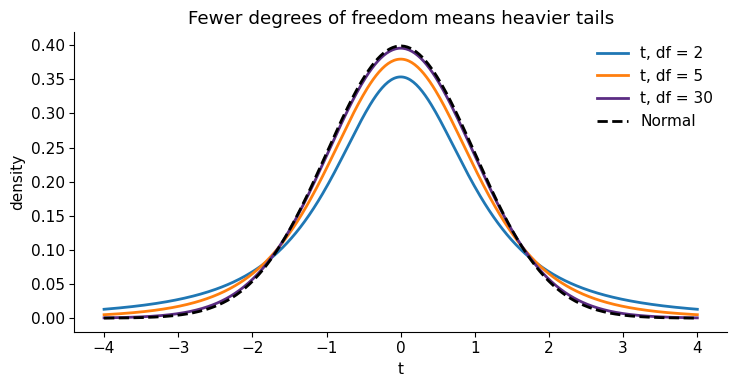

df =    2: 97.5th percentile = 4.303
df =    5: 97.5th percentile = 2.571
df =   30: 97.5th percentile = 2.042
df = 1000: 97.5th percentile = 1.962
   Normal: 97.5th percentile = 1.960


In [9]:
# --- Student's t against the Normal, for a few degrees of freedom
x = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(7.5, 4))
for df in [2, 5, 30]:
    ax.plot(x, stats.t.pdf(x, df), lw=2, label=f"t, df = {df}")
ax.plot(x, stats.norm.pdf(x), lw=2, color="black", ls="--", label="Normal")
ax.set_xlabel("t")
ax.set_ylabel("density")
ax.set_title("Fewer degrees of freedom means heavier tails")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# .ppf is the value with a given probability below it, so this is the cutoff a statistic has
# to beat for a two-sided test at 5%.
for df in [2, 5, 30, 1000]:
    print(f"df = {df:>4}: 97.5th percentile = {stats.t.ppf(0.975, df):.3f}")
print(f"{'Normal':>9}: 97.5th percentile = {stats.norm.ppf(0.975):.3f}")

The lecture spends four slides on the **z-test**, so it is worth doing once rather than only
reading about. The z-test is the t-test with one thing changed: the population standard deviation
is treated as **known**, so the reference distribution is the Normal instead of Student's t.

Written out, on our own measurement:

In [10]:
# --- One z-test, computed once
def z_test(sample, popmean, sigma):
    """One-sample z-test: like a t-test, but with the population SD taken as known."""
    z = (np.mean(sample) - popmean) / (sigma / np.sqrt(len(sample)))
    return z, 2 * stats.norm.sf(np.abs(z))          # both tails of the Normal

values = shift["shift"].to_numpy()

z, p_z = z_test(values, popmean=0.0, sigma=0.10)    # 0.10 treated as if it were known
t_res = stats.ttest_1samp(values, popmean=0.0)

print(f"z = {z:6.2f}   p = {p_z:.1e}")
print(f"t = {t_res.statistic:6.2f}   p = {t_res.pvalue:.1e}   (df = {len(values) - 1})")

z =  16.60   p = 7.3e-62
t =  15.74   p = 9.6e-16   (df = 29)


The two statistics are nearly the same number, because they are the same formula. Both p-values are
far below any threshold anyone uses, and comparing them that deep in the tail means very little.

The question that matters is what happens in the range where decisions actually get made. Nobody
knows the population SD, so the honest question is this: **if you estimate the SD from your sample
and then use the Normal anyway, how often do you reject a null that is true?** It is supposed to be
5%. Let us measure it, the way we measured the p-value distribution in section 1.2.

In [11]:
# --- What using the Normal costs when the SD came from the sample
rng = np.random.default_rng(0)

n_experiments = 5000

print(f"{'n':>5} {'Normal rule':>14} {'t rule':>10}")
for n in [5, 10, 30, 100]:
    normal_rejects = 0
    t_rejects = 0

    # five thousand experiments in a world where the null is exactly true
    for _ in range(n_experiments):
        sample = rng.normal(0, 1, n)
        # the SD is estimated from the sample itself, as it always is in practice
        statistic = sample.mean() / (sample.std(ddof=1) / np.sqrt(n))

        # the same statistic, judged against the two reference distributions
        if 2 * stats.norm.sf(abs(statistic)) < 0.05:
            normal_rejects += 1
        if 2 * stats.t.sf(abs(statistic), n - 1) < 0.05:
            t_rejects += 1

    print(f"{n:>5} {100 * normal_rejects / n_experiments:>13.1f}%"
          f" {100 * t_rejects / n_experiments:>9.1f}%")

    n    Normal rule     t rule


    5          12.2%       5.2%


   10           8.3%       5.2%


   30           6.1%       5.2%


  100           5.0%       4.8%


There it is. With five observations, judging an estimated statistic against the Normal produces a
false positive **more than twice as often as advertised**, 12% of the time instead of 5%. Student's
t holds the promised 5% at every sample size, which is the entire reason it exists.

Notice also how the two columns converge: by n = 100 the Normal is wrong by a few tenths of a per
cent. That is what "t converges to the Normal as the sample grows" means, once it is measured
rather than asserted. The practical rule needs no arithmetic: **if you estimated the standard
deviation from the same sample, use t.** You always did.

Those critical values are the practical consequence. With 30 degrees of freedom you need t of
about 2.04 to reach p = 0.05; with only 2, you need 4.30. Small samples are punished, and
correctly so.

Two functions from `scipy.stats` turn a t value into a p-value and back, and both are used from
here to the end of the notebook. **`stats.t.sf(x, df)`** is the *survival function*, the
probability of a value above `x`, so it is the area in the upper tail; doubling it gives the
two-sided p-value. **`stats.t.ppf(q, df)`** is its inverse, the value with probability `q` below
it, which is where the critical values just quoted come from.

<a id="section-2-2"></a>
## 2.2 From scratch, against scipy 🔬

> 🔬 **Optional.** Writing the test yourself is the quickest cure for treating `ttest_ind` as a black
> box, but everything after this section uses scipy and the function built here is never needed
> again.

One warning before the formula, so that this notebook and the lecture do not seem to disagree.
**Slide 21 defines the unpaired two-sample test as Welch's**, and mentions the pooled version only
as the approximation that holds when the two variances are comparable. That is the right default,
and section 2.3 gets there. We implement the pooled version first because it is the one whose
standard error you can see being built out of the two groups, and because Welch is a modification
of it rather than a different idea.

So, the two-sample (Student) t-test, assuming both groups share a variance:

$$s_p^2 = \frac{(n_A-1)s_A^2 + (n_B-1)s_B^2}{n_A + n_B - 2}, \qquad
t = \frac{\bar{x}_A - \bar{x}_B}{s_p\sqrt{\tfrac{1}{n_A} + \tfrac{1}{n_B}}}$$

with degrees of freedom $n_A + n_B - 2$. Implementing it once is the fastest way to stop thinking
of `ttest_ind` as a black box.

In [12]:
# --- The two-sample t-test, written out, then checked against scipy
def two_sample_t(a, b):
    """Student's two-sample t-test. Returns (t, degrees of freedom, two-sided p)."""
    n_a, n_b = len(a), len(b)
    # the sample variance of each group on its own
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)

    # the pooled variance: the two sample variances, weighted by their degrees of freedom
    pooled_var = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)
    # the standard error of the difference between the two means
    se_difference = np.sqrt(pooled_var * (1 / n_a + 1 / n_b))

    # the t statistic: the difference in means, in units of its own standard error
    t = (np.mean(a) - np.mean(b)) / se_difference
    df = n_a + n_b - 2                   # degrees of freedom of the two-sample test
    p = 2 * stats.t.sf(np.abs(t), df)    # sf is the upper tail, doubled for two sides
    return t, df, p

rng = np.random.default_rng(4)
group_a = rng.normal(0.5, 1.0, 12)     # twelve values, drawn with a mean of 0.5
group_b = rng.normal(0.0, 1.0, 15)     # fifteen values, drawn with a mean of 0

t_ours, df_ours, p_ours = two_sample_t(group_a, group_b)      # our version, unpacked
theirs = stats.ttest_ind(group_a, group_b, equal_var=True)    # and scipy's

print(f"ours : t = {t_ours:.6f}, df = {df_ours}, p = {p_ours:.6f}")
print(f"scipy: t = {theirs.statistic:.6f}, df = {theirs.df:.0f}, p = {theirs.pvalue:.6f}")
assert np.isclose(t_ours, theirs.statistic) and np.isclose(p_ours, theirs.pvalue)
print("\nthey agree")

ours : t = 1.393425, df = 25, p = 0.175757
scipy: t = 1.393425, df = 25, p = 0.175757

they agree


<a id="section-2-3"></a>
## 2.3 Assumptions: Student or Welch

The Student version above assumes the two groups have the **same variance**. When they do not,
it can be badly wrong, and the fix is **Welch's** t-test, which estimates the standard error
without pooling and adjusts the degrees of freedom downwards. `scipy` gives it with
`equal_var=False`, and it is the better default: when the variances really are equal it costs almost
nothing, and when they are not it saves you.

If you want to decide from the data rather than by default, **Levene's test** asks exactly this
question, whether two groups have the same spread, and returns a p-value like any other test. It
appears in the cell below and again in Task 2.2.

The other assumptions: observations should be **independent** (which is why we work with one
number per mouse and not one per trial), and the quantity being averaged should be roughly
**Normal**, or the sample large enough for the Central Limit Theorem to do the work.

Below, a case built to break the pooled version: same means, wildly different spreads and sizes.

In [13]:
# --- When the variances differ, the two tests disagree
rng = np.random.default_rng(7)
small_tight = rng.normal(0.0, 0.5, 8) # sample from a small, tight distribution
large_spread = rng.normal(0.6, 3.0, 40) # sample from a large, spread-out distribution

student = stats.ttest_ind(small_tight, large_spread, equal_var=True)
welch = stats.ttest_ind(small_tight, large_spread, equal_var=False)

print(f"group A: n = {len(small_tight):2d}, SD = {small_tight.std(ddof=1):.2f}")
print(f"group B: n = {len(large_spread):2d}, SD = {large_spread.std(ddof=1):.2f}\n")
# the result object carries the statistic, the degrees of freedom and the p-value
print(f"Student: t = {student.statistic:6.3f}, df = {student.df:5.1f}, p = {student.pvalue:.4f}")
print(f"Welch  : t = {welch.statistic:6.3f}, df = {welch.df:5.1f}, p = {welch.pvalue:.4f}")

# Choosing between them with conditional logic: Levene's test asks whether the variances differ.
levene = stats.levene(small_tight, large_spread)
print(f"\nLevene test for equal variances: p = {levene.pvalue:.4f}")
if levene.pvalue < 0.05:
    print("-> variances look different, use Welch")
else:
    print("-> no evidence against equal variances, Student is fine (Welch still safe)")

group A: n =  8, SD = 0.37
group B: n = 40, SD = 2.60

Student: t =  0.510, df =  46.0, p = 0.6128
Welch  : t =  1.097, df =  44.7, p = 0.2785

Levene test for equal variances: p = 0.0030
-> variances look different, use Welch


<a id="section-2-4"></a>
## 2.4 Effect size and confidence interval

A p-value answers "could this be luck?". It does not answer "is this a lot?". For that we need
the **effect size**, and for two groups the standard one is **Cohen's d**, which is exactly the
standardised difference you built in Week 3:

$$d = \frac{\bar{x}_A - \bar{x}_B}{s_p}$$

Rules of thumb, to be used with suspicion: 0.2 small, 0.5 medium, 0.8 large. They are not laws,
and what counts as large depends entirely on the field.

The **confidence interval** puts the two together. A 95% CI for the difference is

$$(\bar{x}_A - \bar{x}_B) \;\pm\; t^*_{0.975,\,df}\times \text{SE of the difference}$$

and it is more informative than the p-value on its own, because it shows the size of the effect
*and* the uncertainty, in the units of the measurement. If the interval excludes zero, the test
is significant at that alpha, so the CI contains the p-value's answer and more. To compute the
degrees of freedom we will use 
the [Welch-Satterthwaite](https://en.wikipedia.org/wiki/Welch%E2%80%93Satterthwaite_equation) equation.

In [14]:
# --- Cohen's d and a confidence interval for the difference
def cohens_d(a, b):
    """Standardised difference between two groups, using the pooled SD."""
    n_a, n_b = len(a), len(b)
    pooled_var = ((n_a - 1) * np.var(a, ddof=1) + (n_b - 1) * np.var(b, ddof=1)) / (n_a + n_b - 2)
    return (np.mean(a) - np.mean(b)) / np.sqrt(pooled_var)

def difference_ci(a, b, confidence=0.95):
    """Welch confidence interval for the difference between two group means.

    Welch rather than Student, so that this interval and the p-value from
    ttest_ind(..., equal_var=False) always tell the same story: the interval excludes
    zero exactly when the test is significant.
    """
    n_a, n_b = len(a), len(b)
    var_a, var_b = np.var(a, ddof=1), np.var(b, ddof=1)

    # each group contributes its own variance divided by its own size
    term_a = var_a / n_a
    term_b = var_b / n_b

    se = np.sqrt(term_a + term_b)        # the standard error of the difference

    # Welch-Satterthwaite: the effective degrees of freedom
    df = (term_a + term_b) ** 2 / (term_a ** 2 / (n_a - 1) + term_b ** 2 / (n_b - 1))

    # the margin of error: the critical t value for this confidence level, times the SE
    margin = stats.t.ppf(0.5 + confidence / 2, df) * se
    difference = np.mean(a) - np.mean(b)
    return difference - margin, difference + margin

low, high = difference_ci(group_a, group_b)
print(f"difference : {np.mean(group_a) - np.mean(group_b):.3f}")
print(f"95% CI     : [{low:.3f}, {high:.3f}]")
print(f"Cohen's d  : {cohens_d(group_a, group_b):.3f}")
print(f"p-value    : {stats.ttest_ind(group_a, group_b).pvalue:.4f}")

difference : 0.608
95% CI     : [-0.278, 1.494]
Cohen's d  : 0.540
p-value    : 0.1758


> **▶ Task 2.1 ⭐⭐ - Complete the paired test from scratch.**
> The **paired** t-test applies when the same unit is measured twice: it works on the
> **differences** within each unit, and then it is just a one-sample test of those differences
> against zero. That removes all the between-unit variability, which is why pairing is so
> powerful.
>
> Complete the function below so that it returns `(t, df, p)`, and check it against
> `stats.ttest_rel` on the data provided.

In [15]:
# TODO 2.1 - fill in the blanks marked ____, uncomment, and run.

# def paired_t(before, after):
#     """Paired t-test: a one-sample test on the within-unit differences."""
#     differences = np.asarray(before) - np.asarray(after)
#     n = len(differences)
#     mean_difference = np.mean(differences)
#     se = ____                       # (1) SD of the differences divided by sqrt(n)
#     t = ____                        # (2) the mean difference in units of that SE
#     df = n - 1
#     p = 2 * stats.t.sf(np.abs(t), df)       # two-sided: both tails of the t distribution
#     return t, df, p
#
# rng = np.random.default_rng(9)
# before = rng.normal(10, 2, 15)
# after = before + rng.normal(0.8, 1.0, 15)   # the same units, measured twice
#
# t_ours, df_ours, p_ours = paired_t(before, after)
# theirs = stats.ttest_rel(before, after)
#
# print(f"ours : t = {t_ours:.6f}, df = {df_ours}, p = {p_ours:.6f}")
# print(f"scipy: t = {theirs.statistic:.6f}, df = {theirs.df:.0f}, p = {theirs.pvalue:.6f}")

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
rng = np.random.default_rng(9)
before = rng.normal(10, 2, 15)
after = before + rng.normal(0.8, 1.0, 15)      # the same units, measured twice

def paired_t(before, after):
    """Paired t-test: a one-sample test on the within-unit differences."""
    differences = np.asarray(before) - np.asarray(after)
    n = len(differences)
    mean_difference = np.mean(differences)
    se = np.std(differences, ddof=1) / np.sqrt(n)
    t = mean_difference / se
    df = n - 1
    p = 2 * stats.t.sf(np.abs(t), df)
    return t, df, p

t_ours, df_ours, p_ours = paired_t(before, after)      # our version, unpacked
theirs = stats.ttest_rel(before, after)                # and scipy's

print(f"ours : t = {t_ours:.6f}, df = {df_ours}, p = {p_ours:.6f}")
print(f"scipy: t = {theirs.statistic:.6f}, df = {theirs.df:.0f}, p = {theirs.pvalue:.6f}")

unpaired = stats.ttest_ind(before, after)
print(f"\nfor comparison, the UNPAIRED test on the same data: "
      f"t = {unpaired.statistic:.3f}, p = {unpaired.pvalue:.4f}")
print("pairing removes the between-unit spread, so it finds the effect the unpaired test misses")
# --- END SOLUTION

ours : t = -3.259016, df = 14, p = 0.005709
scipy: t = -3.259016, df = 14, p = 0.005709

for comparison, the UNPAIRED test on the same data: t = -1.000, p = 0.3260
pairing removes the between-unit spread, so it finds the effect the unpaired test misses


> **▶ Task 2.2 ⭐⭐ - Let the data choose the test.**
> Complete the function `compare_groups(a, b, alpha=0.05)` below. It runs Levene's test on the two
> groups, picks Student's t-test if the variances look equal and Welch's if they do not, and
> returns a small dictionary with the test it used, t, p, Cohen's d and the 95% interval.
>
> Run it on the two artificial groups from section 2.3. Which test does it choose, and why?

In [16]:
# TODO 2.2 - fill in the blanks marked ____, uncomment, and run.

# def compare_groups(a, b, alpha=0.05):
#     """Compare two groups, choosing Student or Welch according to Levene's test."""
#     equal_variances = stats.levene(a, b).pvalue >= alpha     # do the spreads look the same?
#     result = stats.ttest_ind(a, b, equal_var=____)           # (1) pass the answer through
#     low, high = difference_ci(a, b)
#     return {"test": "Student" if equal_variances else "Welch",
#             "t": round(float(result.statistic), 3),
#             "p": round(float(result.pvalue), 4),
#             "cohens_d": round(float(____), 3),               # (2) the effect size
#             "ci95": (round(float(low), 3), round(float(high), 3))}
#
# print("artificial groups from 2.3:", compare_groups(small_tight, large_spread))

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
def compare_groups(a, b, alpha=0.05):
    """Compare two groups, choosing Student or Welch according to Levene's test."""
    equal_variances = stats.levene(a, b).pvalue >= alpha
    result = stats.ttest_ind(a, b, equal_var=equal_variances)
    low, high = difference_ci(a, b)
    return {"test": "Student" if equal_variances else "Welch",
            "t": round(float(result.statistic), 3),
            "p": round(float(result.pvalue), 4),
            "cohens_d": round(float(cohens_d(a, b)), 3),
            "ci95": (round(float(low), 3), round(float(high), 3))}

print("artificial groups from 2.3:", compare_groups(small_tight, large_spread))
# --- END SOLUTION

artificial groups from 2.3: {'test': 'Welch', 't': 1.097, 'p': 0.2785, 'cohens_d': 0.197, 'ci95': (-0.396, 1.345)}


The cell below computes a 95% confidence interval for the mean shift across the thirty mice. Run it.

In [17]:
# --- A 95% confidence interval for the mean shift across the thirty mice
values = shift["shift"].to_numpy()
n = len(values)

mean = np.mean(values)
sd = np.std(values, ddof=1)
critical = stats.t.ppf(0.975, n - 1)

margin = critical * sd
print(f"mean shift : {mean:.3f}")
print(f"95% CI     : [{mean - margin:.3f}, {mean + margin:.3f}]")

mean shift : 0.303
95% CI     : [0.087, 0.519]


> **▶ Task 2.3 ⭐⭐ - Repair the interval.**
> The interval printed above looks perfectly reasonable and is wrong by a factor of more than five.
>
> Find the mistake and compute the interval correctly below. Check your answer against the width you
> would expect: roughly two standard errors either side of the mean, not two standard deviations.

In [18]:
# TODO 2.3 - your corrected interval here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# The bug: `margin` uses the standard deviation, which describes how much MICE vary, where it
# needs the standard error, which describes how much the MEAN of thirty mice varies. The two
# differ by a factor of sqrt(n), here sqrt(30) = 5.48.
se = sd / np.sqrt(n)
margin = critical * se

print("\nrepaired:")
print(f"mean shift : {mean:.3f}")
print(f"95% CI     : [{mean - margin:.3f}, {mean + margin:.3f}]")
print(f"SD = {sd:.3f}, SE = {se:.3f}, ratio = {sd / se:.2f} = sqrt({n})")
# --- END SOLUTION



repaired:
mean shift : 0.303
95% CI     : [0.264, 0.342]
SD = 0.105, SE = 0.019, ratio = 5.48 = sqrt(30)


<a id="section-3"></a>
# Part 3. Inference on the real data

<a id="section-3-1"></a>
## 3.1 Three comparisons

Now the measurement from Week 3, tested three ways. The same number, the prior-updating
shift, split by three different groupings:

- **genotype**, wild-type against Cntnap2, both from the Angelaki lab, so the lab is held fixed;
- **lab**, the two wild-type cohorts against each other, same genotype, different institutions;
- **sex**, males against females, pooled across all thirty mice.

Only the first is a scientific hypothesis. The second is a **control**: if two groups of ordinary
wild-type mice differ as much as the genotypes do, that is a warning about how much of the first
result is really about genotype. The third is included because it is expected to show nothing,
and seeing a real null result is as instructive as seeing a significant one.

We report each one properly: t, degrees of freedom, p, Cohen's d, and a confidence interval.

> **Three tests, one dataset.** Each test carries its own 5% risk of a false positive, so running
> three of them on data with no effect at all would produce at least one "significant" result about
> 14% of the time rather than 5%. Two things keep us honest here: the three comparisons were chosen
> **before** looking at the results, and we report every one of them, including the null. Week 5
> makes this precise and gives it a name, the family-wise error rate, together with the corrections
> that control it.

In [19]:
# --- The three comparisons, reported in full
def report(name, a, b, label_a, label_b):
    """Run Welch's t-test and return a tidy row with everything worth reporting."""
    # Welch's t-test, which does not assume the two groups have the same variance
    result = stats.ttest_ind(a, b, equal_var=False)
    # the confidence interval, from the function defined above
    low, high = difference_ci(a, b)
    return {"comparison": name,
            "groups": f"{label_a} vs {label_b}",
            "n": f"{len(a)} vs {len(b)}",
            "difference": np.mean(a) - np.mean(b),
            "95% CI": f"[{low:.3f}, {high:.3f}]",
            "t": result.statistic,
            "p": result.pvalue,
            "Cohen's d": cohens_d(a, b)}

# The per-mouse shifts, collected one cohort at a time into a dictionary.
by_cohort = {}
for cohort in COHORT_ORDER:
    mice_of_this_cohort = shift["cohort"] == cohort      # a mask, one True or False per mouse
    by_cohort[cohort] = shift.loc[mice_of_this_cohort, "shift"].to_numpy()

# The same values, split by sex instead of by cohort.
by_sex = {}
for sex in ["M", "F"]:
    mice_of_this_sex = shift["sex"] == sex
    by_sex[sex] = shift.loc[mice_of_this_sex, "shift"].to_numpy()

# One row per comparison, collected in a list and then turned into a table.
rows = []
rows.append(report("genotype", by_cohort["NYU-WT"], by_cohort["CSP-ASD"], "NYU-WT", "CSP-ASD"))
rows.append(report("lab", by_cohort["CSHL-WT"], by_cohort["NYU-WT"], "CSHL-WT", "NYU-WT"))
rows.append(report("sex", by_sex["M"], by_sex["F"], "male", "female"))

table = pd.DataFrame(rows)
print(table.round(4).to_string(index=False))

comparison            groups        n  difference          95% CI       t      p  Cohen's d
  genotype NYU-WT vs CSP-ASD 10 vs 10      0.0659  [0.004, 0.127]  2.2659 0.0375     1.0134
       lab CSHL-WT vs NYU-WT 10 vs 10      0.0978  [0.008, 0.188]  2.3118 0.0346     1.0339
       sex    male vs female 20 vs 10     -0.0439 [-0.135, 0.048] -1.0173 0.3245    -0.4172


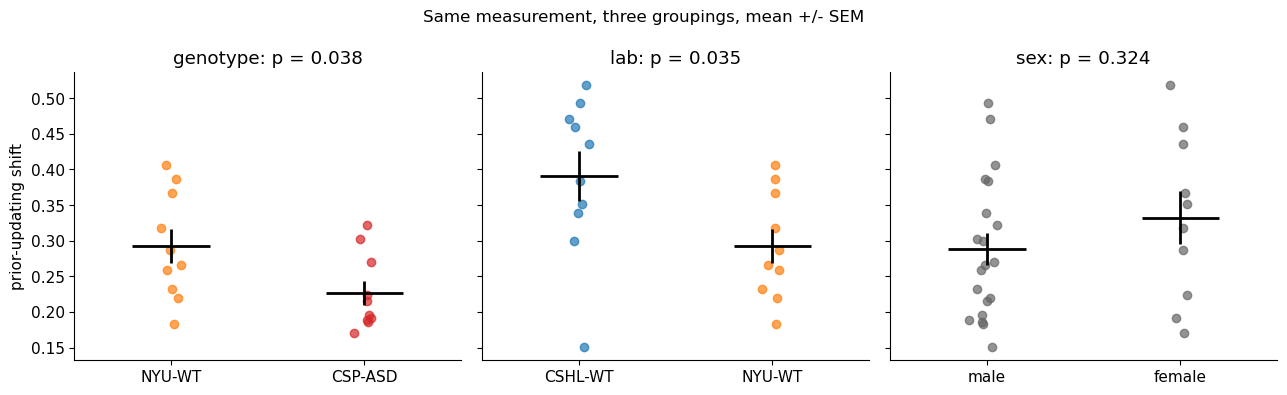

In [20]:
# --- The same three comparisons, drawn
# One function draws one group as a column of dots, so the three panels below stay short.
def draw_group(ax, position, values, label):
    """Draw one group at x = position: its mice as dots, its mean, and its standard error."""
    # a little sideways jitter, so that mice with similar shifts do not land on top of each other
    jitter = np.random.default_rng(position).normal(0, 0.04, len(values))
    colour = COHORT_COLOR.get(label, "0.4")     # cohort colours, grey for male and female
    ax.plot(np.full(len(values), position) + jitter, values, "o", ms=6, alpha=0.7, color=colour)

    mean = values.mean()
    sem = values.std(ddof=1) / np.sqrt(len(values))    # the standard error of that mean
    ax.hlines(mean, position - 0.2, position + 0.2, color="black", lw=2)   # the group mean
    ax.vlines(position, mean - sem, mean + sem, color="black", lw=2)       # plus and minus one SEM

# the p-values computed in the cell above, one per panel
p_genotype = table.loc[table["comparison"] == "genotype", "p"].iloc[0]
p_lab = table.loc[table["comparison"] == "lab", "p"].iloc[0]
p_sex = table.loc[table["comparison"] == "sex", "p"].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)   # three panels sharing a y axis

# Panel 1: genotype, wild-type against the ASD model, both from the Angelaki lab
draw_group(axes[0], 0, by_cohort["NYU-WT"], "NYU-WT")
draw_group(axes[0], 1, by_cohort["CSP-ASD"], "CSP-ASD")
axes[0].set_xticks([0, 1])                              # choose where the ticks go
axes[0].set_xticklabels(["NYU-WT", "CSP-ASD"])          # choose what the ticks say
axes[0].set_title(f"genotype: p = {p_genotype:.3f}")

# Panel 2: lab, the two wild-type cohorts against each other
draw_group(axes[1], 0, by_cohort["CSHL-WT"], "CSHL-WT")
draw_group(axes[1], 1, by_cohort["NYU-WT"], "NYU-WT")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["CSHL-WT", "NYU-WT"])
axes[1].set_title(f"lab: p = {p_lab:.3f}")

# Panel 3: sex, pooled across all thirty mice
draw_group(axes[2], 0, by_sex["M"], "male")
draw_group(axes[2], 1, by_sex["F"], "female")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["male", "female"])
axes[2].set_title(f"sex: p = {p_sex:.3f}")

for ax in axes:
    ax.set_xlim(-0.5, 1.5)          # a little space either side of the two columns

axes[0].set_ylabel("prior-updating shift")
fig.suptitle("Same measurement, three groupings, mean +/- SEM", fontsize=12)  # title for the figure
fig.tight_layout()
plt.show()

Read that table carefully, because it contains the lesson of the week.

The **genotype** comparison is significant at 0.05, with a large Cohen's d. That is the result
the dataset was assembled to show, and it agrees with the published finding that Cntnap2 mice
rely less on prior expectations.

The **lab** comparison is also significant, with an effect size just as large. Two groups of
perfectly ordinary wild-type mice, differing only in which building they were trained in, differ
by about as much as the genotypes do. That does not invalidate the genotype result, which was
measured within a single lab precisely to avoid this. It does mean that anyone comparing the
Churchland wild-types against the Angelaki mutants would have found a "genotype effect" that was
partly a lab effect. Confounding is not a hypothetical.

The **sex** comparison shows nothing, with a p-value nowhere near significance and a small d. This
is a true negative, and the honest way to describe it is "we found no evidence of a difference",
not "we showed there is no difference". With twenty males against ten females, this test would miss
a moderate effect most of the time, as section 3.3 will show.

<a id="section-3-2"></a>
## 3.2 The paired version

There is a better way to ask whether mice use the prior at all. Each mouse gives us **two**
numbers, its choice rate in the 20% blocks and in the 80% blocks. Those are two measurements of
the same animal, so they are paired, and a paired test removes everything that makes one mouse
differ from another.

paired   : t(29) = 15.74, p = 9.565e-16
unpaired : t = 7.49, p = 4.441e-10

mean shift = 0.303, SD across mice = 0.105


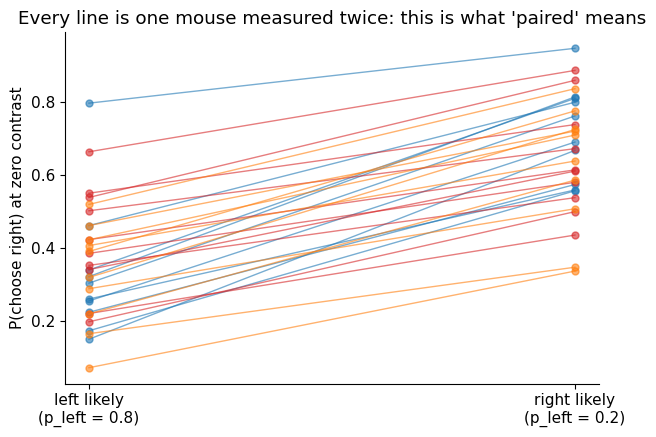

In [21]:
# --- Paired: each mouse measured in both block types
right_likely = shift["p_right_pleft_0.2"].to_numpy()
left_likely = shift["p_right_pleft_0.8"].to_numpy()

# use the paired t-test for the same mice measured twice
paired = stats.ttest_rel(right_likely, left_likely)
# use the unpaired t-test for the same data, ignoring the pairing
unpaired = stats.ttest_ind(right_likely, left_likely)

print(f"paired   : t({len(shift) - 1}) = {paired.statistic:.2f}, p = {paired.pvalue:.3e}")
print(f"unpaired : t = {unpaired.statistic:.2f}, p = {unpaired.pvalue:.3e}")
print(f"\nmean shift = {shift['shift'].mean():.3f}, "
      f"SD across mice = {shift['shift'].std(ddof=1):.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for _, row in shift.iterrows():
    ax.plot([0, 1], [row["p_right_pleft_0.8"], row["p_right_pleft_0.2"]],
            "-o", ms=5, lw=1, alpha=0.6, color=COHORT_COLOR[row["cohort"]])
ax.set_xticks([0, 1])  # choose where the ticks go
# choose what the ticks say
ax.set_xticklabels(["left likely\n(p_left = 0.8)", "right likely\n(p_left = 0.2)"])
ax.set_ylabel("P(choose right) at zero contrast")
ax.set_title("Every line is one mouse measured twice: this is what 'paired' means")
fig.tight_layout()
plt.show()

The paired test gives an enormous t. That is not because the effect got bigger, it is because the
noise got smaller: mice differ a lot from each other in how strongly they use the prior, and
pairing subtracts all of that away before asking the question. Whenever your design lets you
measure the same unit twice, use it.

<a id="section-3-3"></a>
## 3.3 Power, and why n = 10 is a small sample

The genotype comparison came out just under 0.05. That is a result worth having and also a
result worth being nervous about, because with ten mice per group the test is not very powerful.
Let us find out how powerful, by simulation: take the effect size we actually observed, generate
fake experiments of a given size, and count how often they reach significance.

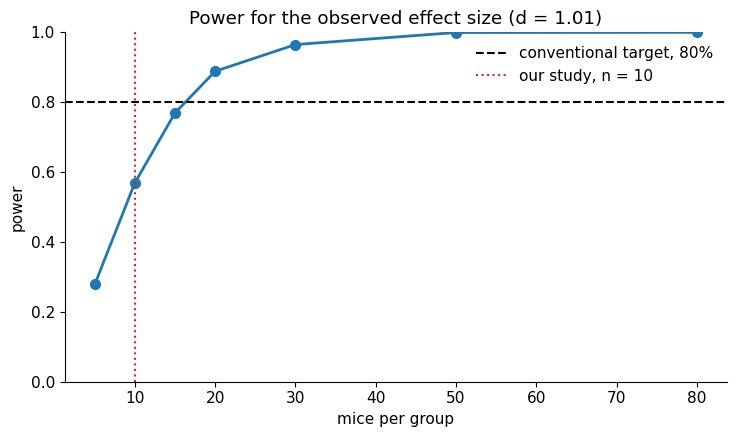

observed Cohen's d : 1.013
  n =   5 per group: power 0.28
  n =  10 per group: power 0.57
  n =  15 per group: power 0.77
  n =  20 per group: power 0.89
  n =  30 per group: power 0.96
  n =  50 per group: power 1.00
  n =  80 per group: power 1.00


In [22]:
# --- Power against sample size, at the effect size we observed
observed_d = cohens_d(by_cohort["NYU-WT"], by_cohort["CSP-ASD"])
rng = np.random.default_rng(12)

def simulate_power(effect_d, n_per_group, rng, n_experiments=2000, alpha=0.05):
    """Fraction of simulated experiments that reach significance.

    The generator is passed in rather than taken from outside the function, so that the
    result depends only on the arguments, as with sampling_distribution in Week 3.
    """
    hits = 0
    for _ in range(n_experiments):
        p = p_value_of_one_experiment(effect_d, rng, n_per_group)   # one whole experiment
        if p < alpha:
            hits += 1
    return hits / n_experiments

sizes = [5, 10, 15, 20, 30, 50, 80]
power_curve = []
for n in sizes:
    power_curve.append(simulate_power(observed_d, n, rng))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(sizes, power_curve, "o-", lw=2, ms=7)
# horizontal reference line
ax.axhline(0.8, color="black", lw=1.5, ls="--", label="conventional target, 80%")
ax.axvline(10, color="#d62728", lw=1.5, ls=":", label="our study, n = 10")
ax.set_xlabel("mice per group")
ax.set_ylabel("power")
ax.set_ylim(0, 1)  # set the range of the vertical axis
ax.set_title(f"Power for the observed effect size (d = {observed_d:.2f})")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"observed Cohen's d : {observed_d:.3f}")
for n, p in zip(sizes, power_curve):
    print(f"  n = {n:>3} per group: power {p:.2f}")

Read the point at n = 10. Even taking the observed effect at face value, an experiment this size
detects it only about half the time. Flip that around: had the mice been slightly less
cooperative, the same real biological effect could easily have produced a p-value comfortably
above 0.05, and no result at all.

This is why a p-value just under 0.05 from a small sample should be reported as a promising
result rather than a settled one, and why the honest thing to publish alongside it is the effect
size and the confidence interval, both of which say plainly how much room for doubt is left.

> **▶ Task 3.1 ⭐⭐ - Design the next experiment.**
> You are planning a replication and want an 80% chance of detecting the effect. Complete the two
> blanks below so that the power curve is computed twice: once at the observed effect size, and
> once at **half** of it, since effects from small significant studies tend to be optimistic. The
> figure is written for you.
>
> Then answer in a comment: what does comparing the two curves say about planning an experiment
> from a previous study's effect size?

  observed d (d = 1.01): need 20 mice per group for 80% power


  half of it (d = 0.51): need more than 60 mice per group for 80% power


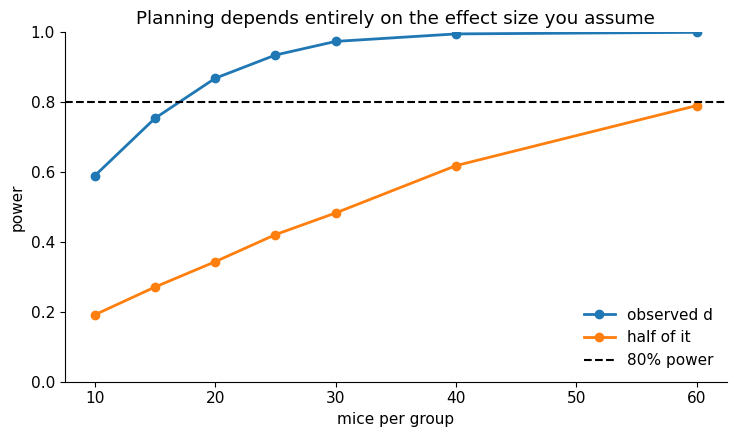

In [23]:
# TODO 3.1 - fill in the blanks marked ____, uncomment, and run.

# sizes = [10, 15, 20, 25, 30, 40, 60]
# curves = {}
# for name, d in [("observed d", observed_d), ("half of it", ____)]:   # (1) half the effect
#     curve = []
#     for n in sizes:
#         curve.append(simulate_power(d, n, rng))
#     curves[name] = curve
#
#     enough = []
#     for n, p in zip(sizes, curve):
#         if p >= ____:            # (2) the 80% target
#             enough.append(n)
#     print(f"{name:>12}: need {enough[0] if enough else 'more than 60'} mice per group")
#
# fig, ax = plt.subplots()
# for name, curve in curves.items():
#     ax.plot(sizes, curve, "o-", lw=2, ms=6, label=name)
# ax.axhline(0.8, color="black", lw=1.5, ls="--", label="80% power")
# ax.set_xlabel("mice per group"); ax.set_ylabel("power"); ax.set_ylim(0, 1)
# ax.legend(frameon=False)
# fig.tight_layout(); plt.show()

# Then answer here: what does comparing the two curves say about planning an experiment
# from a previous study's effect size?

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
sizes = [10, 15, 20, 25, 30, 40, 60]
curves = {}
for name, d in [("observed d", observed_d), ("half of it", observed_d / 2)]:
    curve = []
    for n in sizes:
        curve.append(simulate_power(d, n, rng))
    curves[name] = curve

    enough = []
    for n, p in zip(sizes, curve):
        if p >= 0.8:
            enough.append(n)
    answer = enough[0] if enough else "more than 60"
    print(f"{name:>12} (d = {d if isinstance(d, str) else round(d, 2)}): "
          f"need {answer} mice per group for 80% power")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, curve in curves.items():
    ax.plot(sizes, curve, "o-", lw=2, ms=6, label=name)
ax.axhline(0.8, color="black", lw=1.5, ls="--", label="80% power")
ax.set_xlabel("mice per group"); ax.set_ylabel("power"); ax.set_ylim(0, 1)
ax.set_title("Planning depends entirely on the effect size you assume")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

# Halving the assumed effect roughly quadruples the number of animals required, because power
# depends on d times sqrt(n). Since a small study only reaches significance when luck inflates
# its effect, planning the next experiment from its published d will systematically leave you
# underpowered. Plan for something smaller than what you saw.
# --- END SOLUTION

<a id="section-3-4"></a>
## 3.4 Report one yourself

> **▶ Task 3.2 ⭐⭐⭐ - A comparison, end to end.**
> Everything above was handed to you: the measurement, the groups, the test. Now do one yourself,
> on a different quantity, with nothing scaffolded.
>
> Take the **median reaction time in the trained phase**, one number per mouse, and ask whether the
> two wild-type cohorts differ, `CSHL-WT` against `NYU-WT`. That comparison is about the two
> laboratories rather than about genotype.
>
> Report it the way a paper would, and the way the lecture's checklist asks:
>
> 1. what the design is, and what the unit of analysis is;
> 2. the sample size in each group;
> 3. the null hypothesis, and whether the test is one- or two-sided;
> 4. the test you chose and why;
> 5. the statistic, the degrees of freedom and the p-value;
> 6. the effect size and a confidence interval;
> 7. one sentence of plain-language conclusion, including what the result does **not** say.
>
> Every tool you need is already defined above: `trained`, `cohens_d`, `difference_ci`, and
> `stats` from scipy.
>
> This one is the longest exercise of the notebook and the last: if the session runs out before you
> finish it, it is a good one to take home.

In [24]:
# TODO 3.2 - your analysis and your report here

# --- SOLUTION BELOW: TO BE REMOVED IN THE STUDENT VERSION
# 1 and 2. One number per mouse, which is the unit of analysis: a median reaction time.
valid = trained[trained["reaction_time_s"].between(0.08, 2.0)]
per_mouse = valid.groupby(["cohort", "subject_id"])["reaction_time_s"].median().reset_index()

cshl = per_mouse.loc[per_mouse["cohort"] == "CSHL-WT", "reaction_time_s"].to_numpy()
nyu = per_mouse.loc[per_mouse["cohort"] == "NYU-WT", "reaction_time_s"].to_numpy()
print(f"CSHL-WT: n = {len(cshl)}, median RT {np.mean(cshl):.3f} s")
print(f"NYU-WT : n = {len(nyu)}, median RT {np.mean(nyu):.3f} s")

# 3 and 4. H0: the two cohorts have the same mean of the per-mouse medians. Two-sided, because a
# difference in either direction would be worth knowing. Welch, because the two cohorts are
# different animals in different laboratories and there is no reason to assume equal variances.
result = stats.ttest_ind(cshl, nyu, equal_var=False)
low, high = difference_ci(cshl, nyu)
d = cohens_d(cshl, nyu)

# 5 and 6.
print(f"\nWelch t = {result.statistic:.3f}, df = {result.df:.1f}, p = {result.pvalue:.4f}")
print(f"difference = {np.mean(cshl) - np.mean(nyu):+.3f} s, 95% CI [{low:.3f}, {high:.3f}]")
print(f"Cohen's d  = {d:.2f}")

# 7. In words.
print("""
The CSHL mice are the faster of the two, by about 35 ms of median reaction time, measured on ten
mice per group with one median per mouse. The effect is large on the standardised scale, Cohen's d
close to 0.9, and the p-value still does not clear 0.05: with ten mice per group the confidence
interval runs from a clear difference all the way to nothing at all. A large d with a borderline p
is exactly the situation section 3.3 warned about, which is why the honest conclusion is
"underpowered" rather than "no difference". What the result does not say is that the two
laboratories are equivalent: failing to reject a null is never evidence for it.
""")
# --- END SOLUTION

CSHL-WT: n = 10, median RT 0.171 s
NYU-WT : n = 10, median RT 0.206 s

Welch t = -1.959, df = 16.9, p = 0.0669
difference = -0.035 s, 95% CI [-0.072, 0.003]
Cohen's d  = -0.88

The CSHL mice are the faster of the two, by about 35 ms of median reaction time, measured on ten
mice per group with one median per mouse. The effect is large on the standardised scale, Cohen's d
close to 0.9, and the p-value still does not clear 0.05: with ten mice per group the confidence
interval runs from a clear difference all the way to nothing at all. A large d with a borderline p
is exactly the situation section 3.3 warned about, which is why the honest conclusion is
"underpowered" rather than "no difference". What the result does not say is that the two
laboratories are equivalent: failing to reject a null is never evidence for it.



<a id="section-4"></a>
# 4. What comes next

You can now take a measurement, state a null, choose the right test, run it, and report it in a
way that lets a reader judge it: the statistic, the p-value, the effect size and the interval.
More importantly you have seen what the machinery does not do. It does not prove the null, it
does not measure importance, and it is quietly weak at the sample sizes most animal experiments
actually use.

### The reporting checklist

The list the lecture ends on. Every result you report this year, in this course and outside it,
should carry these seven things. If one of them is missing, a reader cannot judge what you found.

| | What to state |
|---|---|
| 1 | The **design**: what was measured, in whom, and what the unit of analysis is |
| 2 | The **sample size** of each group, and whether the groups are paired |
| 3 | The **hypothesis**: the null, and one- or two-sided |
| 4 | The **test** used, and why that one |
| 5 | The **statistic**, its degrees of freedom and the **exact p-value**, not just "p < 0.05" |
| 6 | The **effect size** and a **confidence interval** |
| 7 | A plain-language conclusion, including what the result does not say |

Two threads continue directly:

- We tested three comparisons on one dataset today, and picked them in advance. Week 5 asks
  what happens when you test **many** things at once, which is where family-wise error, the false
  discovery rate and p-hacking come in, and it generalises the t-test to more than two groups
  with the **ANOVA**.
- Our tests assumed roughly Normal data and were run on thirty mice. Week 6 drops that
  assumption and gets its p-values by **resampling** instead, which works when the assumption
  does not.